In [1]:
import torch
import os
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

from src.train_bimodal import *
from src.train_realnvp import *

# Preliminary experiments with bimodal Gaussian mixtures

In the following we explore 3 different learning strategies.

In [2]:
device = torch.device('mps')

#parameters of the simulation
dim = 128
radius = 3
w_star = 4/5

# setting up the target distribution
target_means = torch.zeros(2, dim, device=device)
target_means[0,0] = radius
target_means[1,0] = -radius
target_vars = torch.tensor([1, 1], device=device)
target_weights = torch.tensor([w_star, 1-w_star], device=device)

target = MIG(target_means, target_vars, target_weights, device=device)

In [5]:
### first run: no annealing ###
# The following config file is the same as the .json config file needed to run the main_bimodal_gaussian.py script
config1 = {
    "teacher_param": {"dim": dim, "radius": radius, "weight": w_star},
    "model_param": {"seed": 0,"weight": 0.5},
    "opt_param": {"seed": 0,"n_iter": 100,"learning_rate": 5e-2,"n_batch": 1024,"n_checkpoints": 1},
    "annealing_param": {"type": "exp","beta_i": 1.,"t0": 1.0}
}

torch.manual_seed(config1['model_param']['seed'])

# setting up the initial student distribution
means = nn.Parameter(torch.randn(2, dim, device=device))
means.data = radius * (means.data / ((means.data**2).sum(dim=1)[:,None])**0.5)
vars = nn.Parameter(torch.tensor([1., 1.], device=device))
weights = torch.tensor([config1['model_param']['weight'], 1-config1['model_param']['weight']], device=device)

model = MIG(means, vars, weights, device=device)

res1 = train_bimodal(model, target, config1)

In [6]:
#second run: no annealing with high variance initialization
var_i = 10.0*radius**2
config2 = {
    "teacher_param": {"dim": dim, "radius": radius, "weight": w_star},
    "model_param": {"seed": 0,"weight": 0.5},
    "opt_param": {"seed": 0,"n_iter": 100,"learning_rate": 5e-2,"n_batch": 1024,"n_checkpoints": 1},
    "annealing_param": {"type": "exp","beta_i": 1,"t0": 1.0}
}

torch.manual_seed(config2['model_param']['seed'])

#model
means = nn.Parameter(torch.randn(2, dim, device=device))
means.data = radius * (means.data / ((means.data**2).sum(dim=1)[:,None])**0.5)
vars = nn.Parameter(torch.tensor([var_i, var_i], device=device))
weights = torch.tensor([config2['model_param']['weight'], 1-config2['model_param']['weight']], device=device)

model = MIG(means, vars, weights, device=device)

res2 = train_bimodal(model, target, config2)

In [7]:
#third run: annealing
config3 = {
    "teacher_param": {"dim": dim, "radius": radius, "weight": w_star},
    "model_param": {"seed": 0,"weight": 0.5},
    "opt_param": {"seed": 0,"n_iter": 800,"learning_rate": 5e-2,"n_batch": 8*1024,"n_checkpoints": 1},
    "annealing_param": {"type": "exp","beta_i": 1/radius**2/10,"t0": 700}
}

torch.manual_seed(config3['model_param']['seed'])

#model
means = nn.Parameter(torch.randn(2, dim, device=device))
means.data = radius * (means.data / ((means.data**2).sum(dim=1)[:,None])**0.5)
vars = nn.Parameter(torch.tensor([1/config3['annealing_param']['beta_i'], 1/config3['annealing_param']['beta_i']], device=device))
weights = torch.tensor([config3['model_param']['weight'], 1-config3['model_param']['weight']], device=device)

model = MIG(means, vars, weights, device=device)

res3 = train_bimodal(model, target, config3)

### Plot of results

In [8]:
# Time indices to plot for each experiment
indices1=[0,33,66,99]
indices2 = [0, 33, 66, 99]
indices3 = [0, 133, 266, 699]

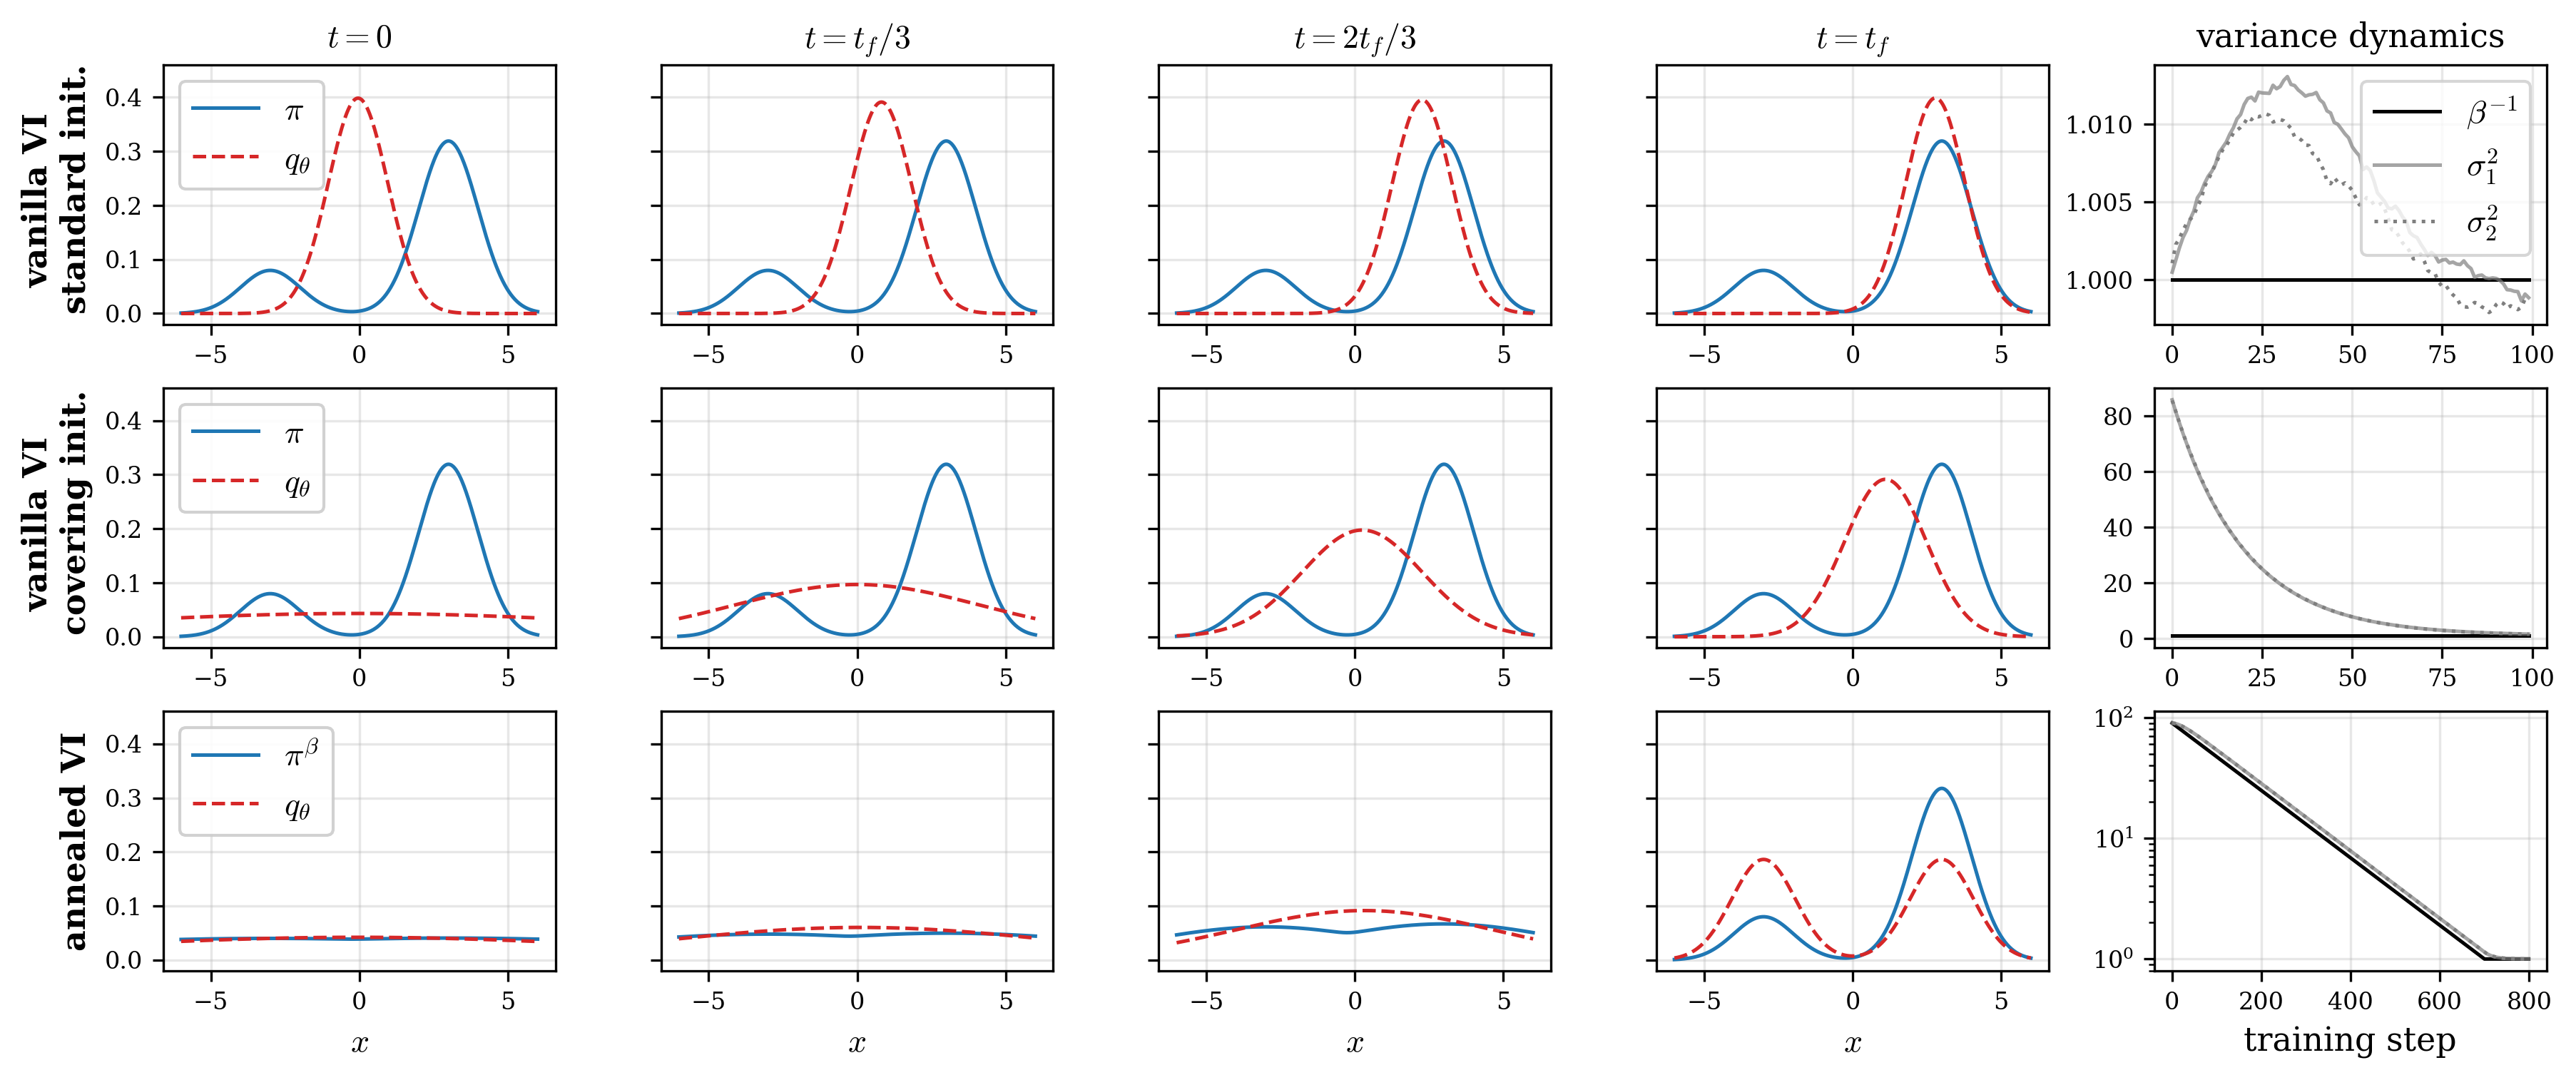

In [9]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 11,
    "lines.linewidth": 1.2,
    "grid.alpha": 0.3
})

# Color Palette: Professional and high-contrast
C_TARGET = '#1f77b4'  # Blue
C_MODEL = '#d62728'   # Red (dashed)
C_BETA = '#2ca02c'    # Green
C_SIGMA = '#7f7f7f'   # Gray

titles = ["$t=0$", "$t=t_f/3$", "$t=2t_f/3$", "$t=t_f$"]
row_labels = ["vanilla VI \n standard init.", "vanilla VI \n covering init.", "annealed VI"] # Customize these based on your data

fig, axes = plt.subplots(3, 5, figsize=(12, 5), dpi=300)

x_range = torch.linspace(-2*radius, 2*radius, 500)
x_norm = torch.linspace(-5*radius, 5*radius, 10000)

def plot_row(row_idx, res, config, indices, is_annealed_target=False):
    # Marginal Distribution Plots
    for i, t in enumerate(indices):
        ax = axes[row_idx, i]
        
        target_log = log_marginal_along_mu(radius, torch.tensor([1, -1]), torch.tensor([1,1]), torch.tensor([w_star, 1-w_star]), x_range)
        
        if is_annealed_target:
            # Row 3 specific normalization logic
            log_Z_data = log_marginal_along_mu(radius, torch.tensor([-1, 1]), torch.tensor([1,1]), torch.tensor([w_star, 1-w_star]), x_norm)
            log_Z = torch.logsumexp(torch.log((x_norm[-1]-x_norm[0])/len(x_norm)) + res['betas'][t] * log_Z_data, dim=0)
            target_p = torch.exp(res['betas'][t] * target_log - log_Z)
            label_target = r"$\pi^\beta$"
        else:
            target_p = torch.exp(target_log)
            label_target = r"$\pi$"

        model_log = log_marginal_along_mu(radius, 
                                          torch.tensor([res['m1'][t], res['m2'][t]]), 
                                          torch.tensor([res['var1'][t], res['var2'][t]]), 
                                          torch.tensor([config['model_param']['weight'], config['model_param']['weight']]), 
                                          x_range)
        
        ax.plot(x_range, target_p, color=C_TARGET, label=label_target)
        ax.plot(x_range, torch.exp(model_log), color=C_MODEL, linestyle="--", label=r"$q_\theta$")
        
        ax.grid(True)
        if row_idx == 0: ax.set_title(titles[i])
        if i == 0: ax.set_ylabel(row_labels[row_idx], fontweight='bold')
        if row_idx == 2: ax.set_xlabel('$x$')

    # Variance/Annealing Dynamics Plot (Column 5)
    ax_v = axes[row_idx, 4]
    ax_v.plot(1/np.array(res['betas']), color='black', label=r'$\beta^{-1}$')
    ax_v.plot(res['var1'], color=C_SIGMA, alpha=0.7, label=r'$\sigma_1^2$')
    ax_v.plot(res['var2'], color=C_SIGMA, linestyle=':', label=r'$\sigma_2^2$')
    ax_v.grid(True)
    if row_idx ==0: ax_v.set_title('variance dynamics')
    if row_idx == 2: ax_v.set_xlabel('training step')
    return axes[row_idx, 0]

# Execute plotting
plot_row(0, res1, config1, indices1)
plot_row(1, res2, config2, indices2)
plot_row(2, res3, config3, indices3, is_annealed_target=True)

# Post-processing for clarity
axes[0, 0].legend(loc='upper left', frameon=True, framealpha=0.9)
axes[1, 0].legend(loc='upper left', frameon=True, framealpha=0.9)
axes[2, 0].legend(loc='upper left', frameon=True, framealpha=0.9)
axes[0, 4].legend(loc='upper right')
axes[2, 4].set_yscale('log')

# Unify Y-limits for all marginals
ymin, ymax = axes[0, 0].get_ylim()
for r in range(3):
    for c in range(4):
        axes[r, c].set_ylim(ymin, ymax * 1.1)
        if c > 0: axes[r, c].set_yticklabels([]) # Remove redundant labels

plt.tight_layout(pad=0.5)


filename = "figures/preliminary_experiment.pdf"
#plt.savefig(filename, bbox_inches='tight')
plt.show()

# Agreement with the theoretical ODE

The functions $f$ and $g$ defined in the article and called in the following cells are implemented in src.utils.py.

In [10]:
# Opt parameters of the third experiment
betas=res3['betas'][1:]
lr = config3['opt_param']['learning_rate']

# Initial condition of third preliminary experiment
m1_th = [res3['m1'][0]]
m2_th = [res3['m2'][0]]
s_th = [res3['s'][0]]

w1 = config3['model_param']['weight']

In [11]:
# Numerical integration of the ODE
for t in tqdm(range(len(betas))):
    u = betas[t]**(-0.5)
    m1, m2, s = m1_th[-1], m2_th[-1], s_th[-1]
    f_value, g1_value, g2_value = f(s, w1, radius, u), g(m1, w_star, radius, u), g(m2, w_star, radius, u)

    m1_th.append( m1 - lr * ((m2-m1*s)*f_value + w1*(1-m1**2)*g1_value) )
    m2_th.append( m2 - lr * ((m1-m2*s)*f_value + (1-w1)*(1-m2**2)*g2_value) )
    s_th.append( s - lr  * (2*(1-s**2)*f_value + w1*(m2-m1*s)*g1_value + (1-w1)*(m1-m2*s)*g2_value) )

res3_th = {'m1': np.array(m1_th), 'm2': np.array(m2_th), 's': np.array(s_th)}

100%|██████████| 799/799 [00:00<00:00, 1413.02it/s]


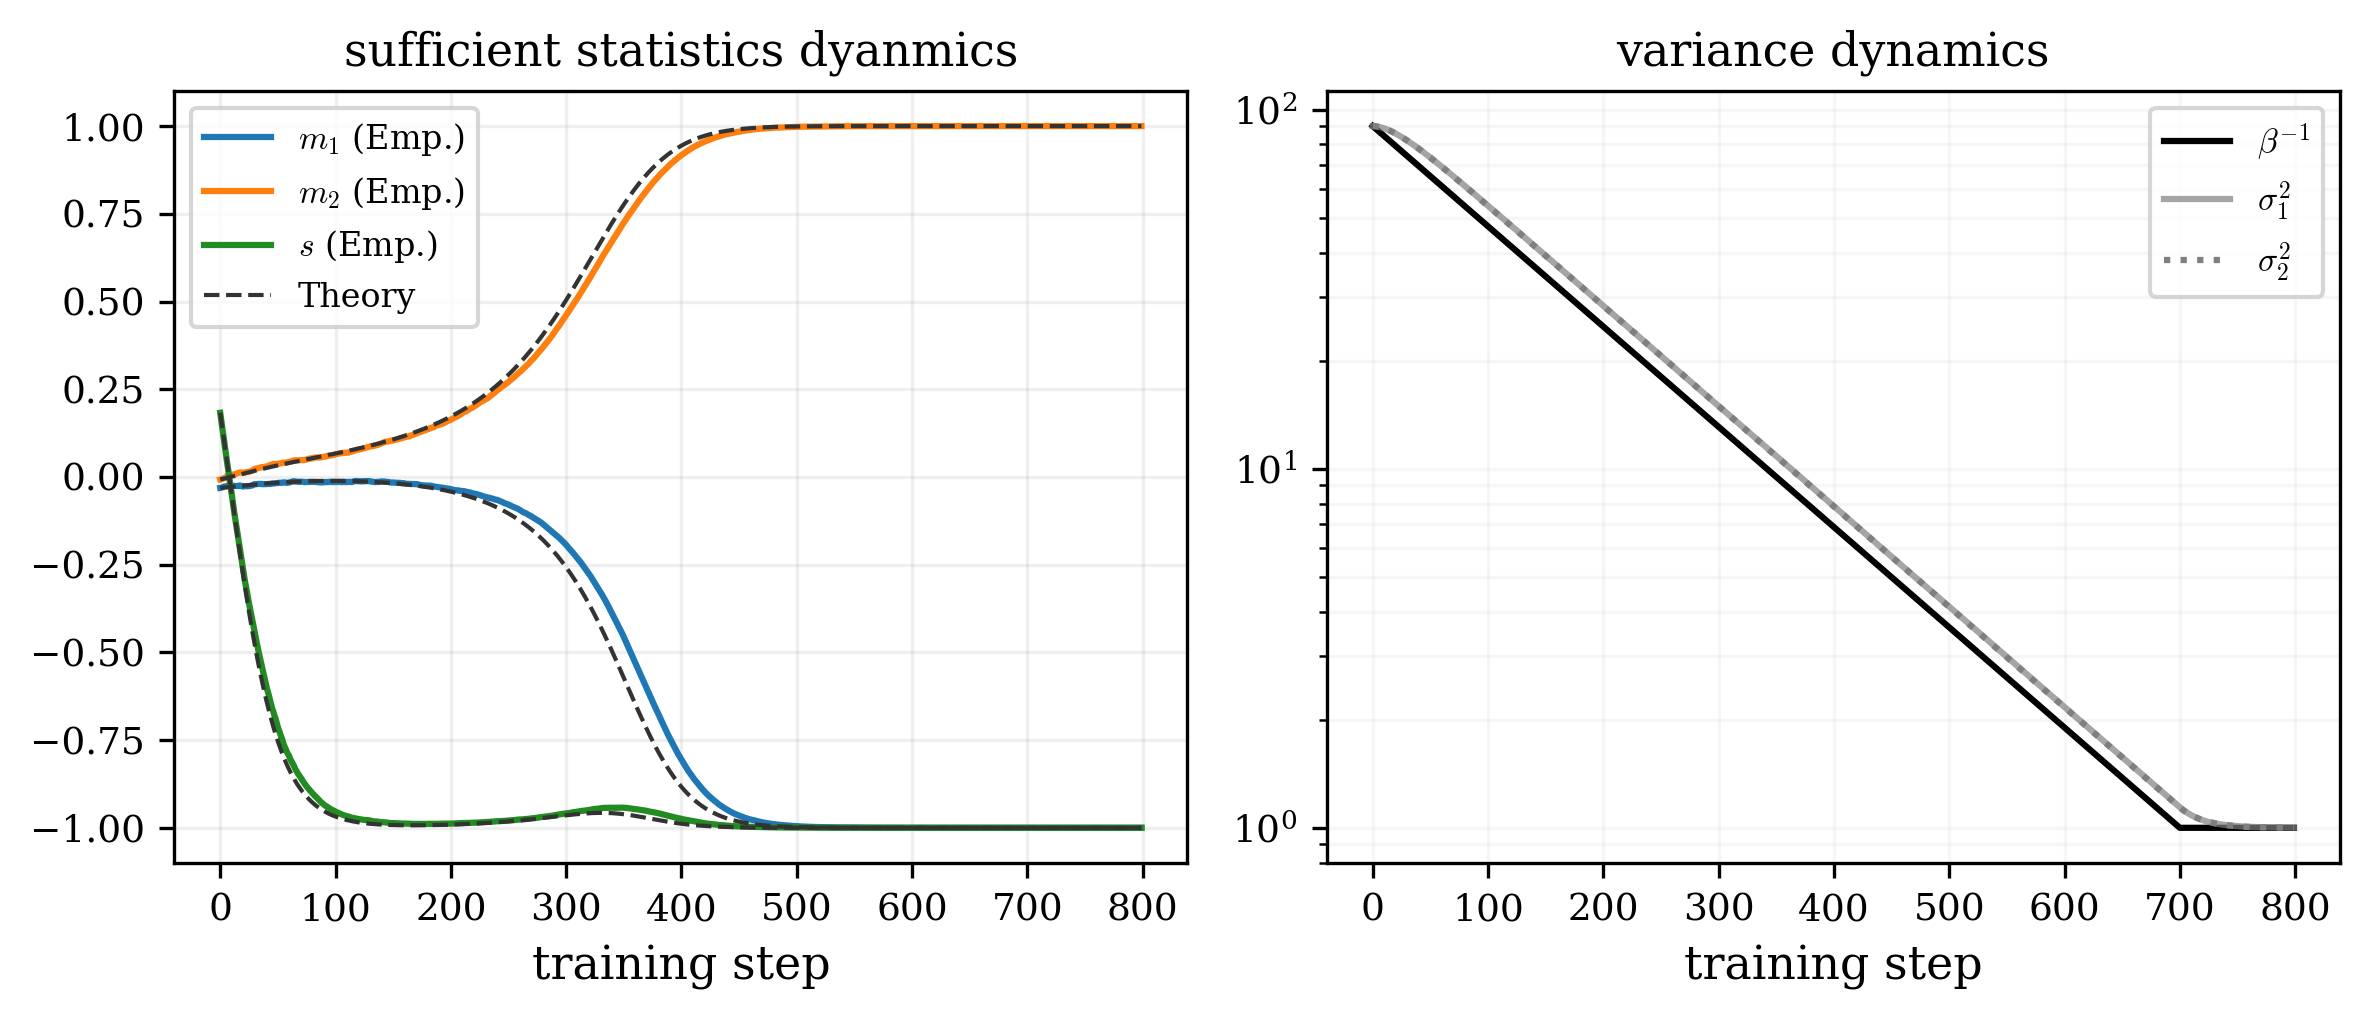

In [12]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
    "grid.alpha": 0.2
})

# Color Palette
C1 = '#1f77b4' # Blue
C2 = '#ff7f0e' # Orange
C_TH = '#333333' # Dark Gray for theory
C_SIGMA = '#7f7f7f'   # Gray

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5), dpi=300)

# --- left plot: sufficient statistics ---
ax1.plot(res3['m1'], color=C1, label=r'$m_1$ (Emp.)')
ax1.plot(res3['m2'], color=C2, label=r'$m_2$ (Emp.)')
ax1.plot(res3['s'], color='forestgreen', label=r'$s$ (Emp.)')

ax1.plot(res3_th['m1'], color=C_TH, linestyle='--', linewidth=1, label='Theory')
ax1.plot(res3_th['m2'], color=C_TH, linestyle='--', linewidth=1)
ax1.plot(res3_th['s'], color=C_TH, linestyle='--', linewidth=1)

ax1.set_xlabel('training step')
ax1.set_title('sufficient statistics dyanmics')
ax1.legend(loc='best', frameon=True, fontsize=8)
ax1.grid(True)

# --- right plot: variance dynamics ---
ax2.plot(1/np.array(res3['betas']), color='black', label=r'$\beta^{-1}$')
ax2.plot(res3['var1'], color=C_SIGMA, alpha=0.7, label=r'$\sigma_1^2$')
ax2.plot(res3['var2'], color=C_SIGMA, linestyle=':', label=r'$\sigma_2^2$')

ax2.set_yscale('log')
ax2.set_xlabel('training step')
ax2.set_title('variance dynamics')
ax2.legend(loc='best', frameon=True, fontsize=8)
ax2.grid(True, which="both", ls="-", alpha=0.1)

plt.tight_layout()


filename = "figures/dynamical_system_validation.pdf"
#plt.savefig(filename, bbox_inches='tight')
plt.show()

# Experiments with RealNVP

Example of train_realnvp.py implementation.

In [16]:
device = torch.device('mps')

#Hyperparameters
dim = 128
radius = 3
w_star = 4/5

# The following configuration .json contains all the parameters of the simulation
config = {
    "teacher_param": {"dim": dim, "radius": radius, "weight": w_star, "seed":0},
    "nf_param": {"seed": 0,"num_layers": 8, "hidden_dim": 128*4},
    "opt_param": {"seed": 0,"n_iter": 700,"learning_rate": 1e-3,"n_batch": 1024,"n_checkpoints": 1},
    "annealing_param": {"type": "exp","beta_i": 0.111111,"t0": 600.0}
}

In [17]:
#setting up the teacher
torch.manual_seed(config['teacher_param']['seed'])

mu_star = torch.randn(dim, device=device)
mu_star = mu_star / torch.norm(mu_star)
target_means = torch.stack([radius*mu_star, -radius*mu_star])
target_vars = torch.tensor([1., 1.], device=device)
target_weights = torch.tensor([w_star, 1-w_star], device=device)
target = MIG(target_means, target_vars, target_weights, device=device)

In [18]:
# setting up the model
torch.manual_seed(config['nf_param']['seed'])
flow = RealNVP(config['nf_param']['num_layers'], dim, config['nf_param']['hidden_dim'], device=device)

In [19]:
# training loop (be careful to run on gpu. this might take a minute)
res = train_realnvp(flow, target, config)

### Plotting the results

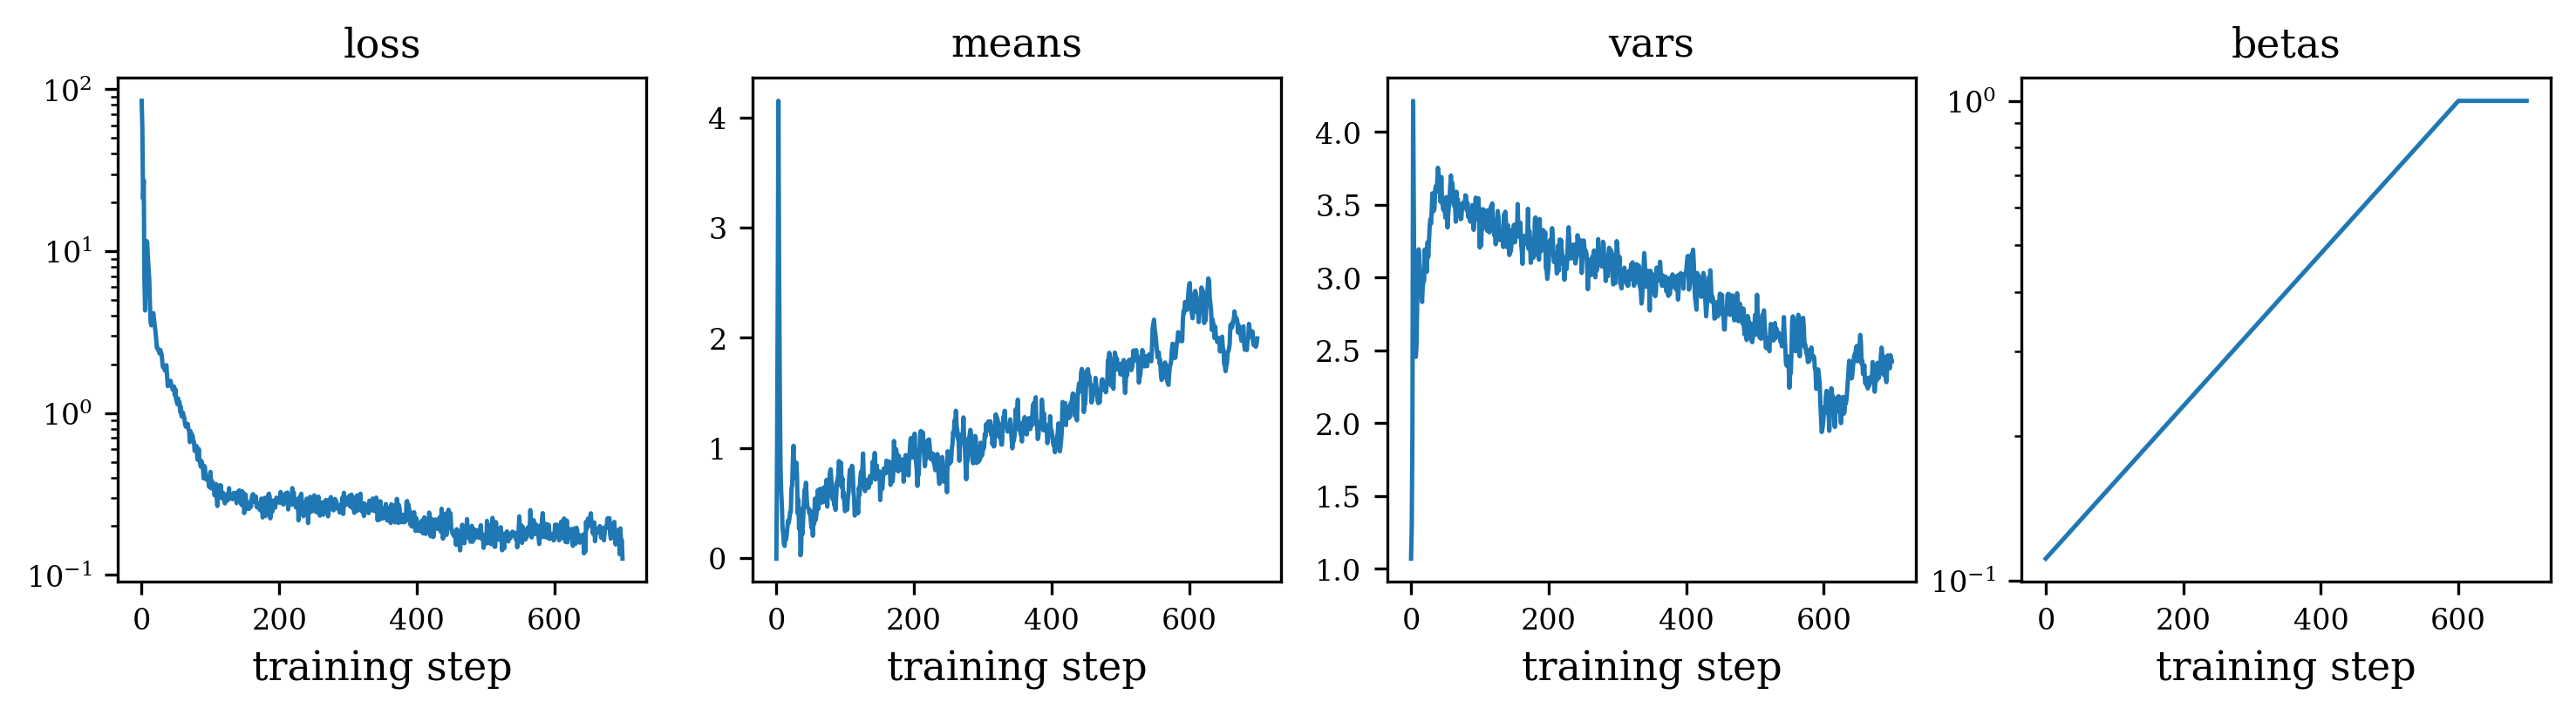

In [20]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 11,
    "lines.linewidth": 1.2,
    "grid.alpha": 0.3
})

fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), dpi=300, sharex=True)

axes[0].plot(res['losses'])

axes[1].plot(res['means'])

axes[2].plot(res['vars'])

axes[3].plot(res['betas'])

# Post-processing for clarity
axes[0].set_yscale('log')
axes[3].set_yscale('log')

axes[0].set_title('loss')
axes[1].set_title('means')
axes[2].set_title('vars')
axes[3].set_title('betas')
axes[0].set_xlabel('training step')
axes[1].set_xlabel('training step')
axes[2].set_xlabel('training step')
axes[3].set_xlabel('training step')

filename = "figures/realnvp_preliminary_exp.pdf"
#plt.savefig(filename, bbox_inches='tight')
plt.show()